# Notebook 10 — MAML + Transformer (First-Order MAML)

**Method:** Finn et al., *Model-Agnostic Meta-Learning for Fast Adaptation of Deep Networks*,  
ICML 2017  
**HAR domain references:**  
- Nie et al., *MAML-CFCNN for HAR*, Pattern Recognition Letters 2022  
- Bian et al., *Bridging Gen & Personalization*, 2025

**Core idea:**  
Learn an initialization θ such that a few gradient steps on any new user's  
K-shot support set leads to good performance for that user.

**FOMAML (First-Order approximation):**  
The original MAML requires differentiating through the inner loop optimization  
(second-order gradients), which is expensive. FOMAML drops the second-order  
terms — the outer gradient is computed as if the adapted parameters θ'  
were the same as θ. This gives 80-90% of MAML's performance at a fraction  
of the compute cost.

**Two-phase structure:**
```
Phase A — Meta-training:
  For each episode:
    1. Clone backbone parameters → θ_clone
    2. Inner loop: take MAML_INNER_STEPS steps on support loss using θ_clone
    3. Compute query loss using θ_clone (adapted)
    4. Outer loop: update original θ using query loss gradient
       (FOMAML: gradient flows back through θ_clone to θ directly)

Phase B — Personalization (test time):
  For each test user:
    1. Clone meta-learned θ
    2. Inner loop: take steps on K-shot support
    3. Evaluate on remaining user samples
```

**Note:** While MAML is backbone-agnostic, it pairs especially naturally  
with the Transformer backbone (the paper title in our plan reflects this).  
However this notebook works with all three backbones.

---
**Requires:** notebook 00, preprocessing notebook, backbone checkpoint.

**Justification - MAML Scheduler:** MAML utilized a StepLR, halving the learning rate every 20 epochs. This ensures that meta-adaptation finely tunes the embedding space rather than destructively overwriting the representations learned during base training.

## Cell 1 — Setup and Install

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

%run "/content/drive/MyDrive/Colab Notebooks/00_config_and_utils.ipynb"

import copy
import collections

# ─── Configuration ────────────────────────────────────────────────────────────
DATASET_NAME   = 'wisdm'
BACKBONE_TYPE  = 'cnn'    # 'cnn' | 'lstm' | 'transformer'

# FOMAML hyperparameters (from global config in notebook 00)
# MAML_INNER_LR    = 0.005  (inner loop step size)
# MAML_INNER_STEPS = 5     (gradient steps per task)
# MAML_OUTER_LR    = 5e-4  (meta-optimizer LR)

print(f'\n✅ Setup complete')
print(f'   Method        : FOMAML (First-Order MAML)')
print(f'   Dataset       : {DATASET_NAME}')
print(f'   Backbone      : {BACKBONE_TYPE}')
print(f'   Inner LR      : {MAML_INNER_LR}')
print(f'   Inner steps   : {MAML_INNER_STEPS}')
print(f'   Outer LR      : {MAML_OUTER_LR}')
print(f'   Device        : {DEVICE}')

Mounted at /content/drive
✅ Imports OK
   PyTorch  : 2.10.0+cu128
   NumPy    : 2.0.2
   CUDA     : True
   GPU      : Tesla T4
✅ Seeded everything with MASTER_SEED=42
✅ Global hyperparameters set
   Target frequency : 50 Hz
   Window size      : 250 samples (5.0 sec)
   Window stride    : 125 samples (2.5 sec)
   K shots          : [1, 5, 10]
   N way (default)  : 5
   Embedding dim    : 128
   Device           : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths configured
   Processed data  → /content/drive/MyDrive/fsl_har_processed
   Checkpoints     → /content/drive/MyDrive/fsl_har_checkpoints
   Results         → /content/drive/MyDrive/fsl_har_results
✅ Dataset configs loaded
   wisdm                  →  51 subjects |  18 classes |  4 streams | n_way=5
   cogage_atomic          →   8 subjects |  61 classes |  9 streams | n_way=5
   cogage_composite       →   6 subjects |   7 classes | 10 st

## Cell 2 — Load Dataset and Backbone

In [ ]:
# ─── Backbone class definitions matching notebook 05/06/07 exactly ────────────
import torch.nn as nn
import torch.nn.functional as F

# ── CNN (matches notebook 05) ──────────────────────────────────────────────────
class StreamCNNEncoder(nn.Module):
    def __init__(self, in_channels, d_stream=64):
        super().__init__()
        self.encoder = nn.Sequential(
            # indices 0,1,2,3,4
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),  # 0
            nn.BatchNorm1d(32),                                      # 1
            nn.ReLU(),                                               # 2
            nn.Dropout(0.1),                                         # 3
            nn.MaxPool1d(2),                                         # 4
            # indices 5,6,7,8,9
            nn.Conv1d(32, 64, kernel_size=5, padding=2),            # 5
            nn.BatchNorm1d(64),                                      # 6
            nn.ReLU(),                                               # 7
            nn.Dropout(0.1),                                         # 8
            nn.MaxPool1d(2),                                         # 9
            # indices 10,11,12,13
            nn.Conv1d(64, d_stream, kernel_size=3, padding=1),      # 10
            nn.BatchNorm1d(d_stream),                                # 11
            nn.ReLU(),                                               # 12
            nn.AdaptiveAvgPool1d(1),                                 # 13
        )
        self.d_stream = d_stream

    def forward(self, x):
        # x: (B, T, C) → permute to (B, C, T) for Conv1d
        return self.encoder(x.permute(0, 2, 1)).squeeze(-1)  # (B, d_stream)

class CNNBackbone(nn.Module):
    def __init__(self, n_streams, n_classes, in_channels=3,
                 d_stream=64, embedding_dim=128):
        super().__init__()
        self.stream_encoders = nn.ModuleList(
            [StreamCNNEncoder(in_channels, d_stream) for _ in range(n_streams)]
        )
        self.fusion = nn.Sequential(
            nn.Linear(n_streams * d_stream, embedding_dim),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(embedding_dim, n_classes)

    def get_embedding(self, stream_list):
        feats = [enc(x) for enc, x in zip(self.stream_encoders, stream_list)]
        return self.fusion(torch.cat(feats, dim=-1))

    def forward(self, stream_list, return_embedding=False):
        emb = self.get_embedding(stream_list)
        if return_embedding:
            return emb
        return self.classifier(emb)


# ── LSTM (matches notebook 06) ─────────────────────────────────────────────────
class StreamLSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.hidden_size = hidden_size

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return h[-1]


class LSTMBackbone(nn.Module):
    def __init__(self, n_streams, n_classes, input_size=3,
                 hidden_size=64, num_layers=2, dropout=0.3, embedding_dim=128):
        super().__init__()
        self.stream_encoders = nn.ModuleList(
            [StreamLSTMEncoder(input_size, hidden_size, num_layers, dropout)
             for _ in range(n_streams)]
        )
        self.fusion = nn.Sequential(
            nn.Linear(n_streams * hidden_size, embedding_dim),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(embedding_dim, n_classes)

    def get_embedding(self, stream_list):
        feats = [enc(x) for enc, x in zip(self.stream_encoders, stream_list)]
        return self.fusion(torch.cat(feats, dim=-1))

    def forward(self, stream_list, return_embedding=False):
        emb = self.get_embedding(stream_list)
        if return_embedding:
            return emb
        return self.classifier(emb)


# ── Transformer (matches notebook 07) ─────────────────────────────────────────
class StreamTransformerEncoder(nn.Module):
    def __init__(self, in_channels, d_model=64):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, d_model)
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        out = self.input_proj(x)                          # (B, T, d_model)
        return self.pool(out.permute(0, 2, 1)).squeeze(-1)  # (B, d_model)


class TransformerBackbone(nn.Module):
    def __init__(self, n_streams, n_classes, in_channels=3,
                 d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=256, dropout=0.1, embedding_dim=128):
        super().__init__()
        self.stream_encoders = nn.ModuleList(
            [StreamTransformerEncoder(in_channels, d_model)
             for _ in range(n_streams)]
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fusion = nn.Sequential(
            nn.Linear(n_streams * d_model, embedding_dim),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(embedding_dim, n_classes)

    def get_embedding(self, stream_list):
        tokens = torch.stack(
            [enc(x) for enc, x in zip(self.stream_encoders, stream_list)],
            dim=1
        )                                                    # (B, n_streams, d_model)
        out  = self.transformer(tokens)                      # (B, n_streams, d_model)
        flat = out.reshape(out.size(0), -1)                  # (B, n_streams * d_model)
        return self.fusion(flat)

    def forward(self, stream_list, return_embedding=False):
        emb = self.get_embedding(stream_list)
        if return_embedding:
            return emb
        return self.classifier(emb)

# ─── Load dataset ──────────────────────────────────────────────────────────────
data = load_processed_dataset(DATASET_NAME)

streams      = data['streams']
y            = data['y']
subject_ids  = data['subject_ids']
stream_names = data['stream_names']
split_info   = data['split_info']
cfg          = data['config']
sam          = data.get('subject_activity_map')

n_streams = len(stream_names)
n_classes = cfg['n_classes']
n_way     = cfg['n_way']
N, T, C   = streams[stream_names[0]].shape

# Force both sides to strings for bulletproof matching
sub_ids_str = subject_ids.astype(str)
train_split = [str(s) for s in split_info['train']]
val_split   = [str(s) for s in split_info['val']]
test_split  = [str(s) for s in split_info['test']]

# Build subject masks
train_mask = get_split_mask(sub_ids_str, train_split)
val_mask   = get_split_mask(sub_ids_str, val_split)
test_mask  = get_split_mask(sub_ids_str, test_split)

print(f'── Dataset: {DATASET_NAME} ──')
print(f'   Windows : {N:,}  |  streams: {n_streams}  |  classes: {n_classes}')

# ─── Build backbone kwargs based on type ──────────────────────────────────────
if BACKBONE_TYPE == 'cnn':
    BackboneClass   = CNNBackbone
    backbone_kwargs = dict(n_streams=n_streams, n_classes=n_classes,
                           in_channels=C, d_stream=64, embedding_dim=EMBEDDING_DIM)
elif BACKBONE_TYPE == 'lstm':
    BackboneClass   = LSTMBackbone
    backbone_kwargs = dict(n_streams=n_streams, n_classes=n_classes,
                           input_size=C, hidden_size=64, num_layers=2,
                           dropout=0.3, embedding_dim=EMBEDDING_DIM)
elif BACKBONE_TYPE == 'transformer':
    BackboneClass   = TransformerBackbone
    backbone_kwargs = dict(n_streams=n_streams, n_classes=n_classes,
                           in_channels=C, d_model=64, nhead=4, num_layers=2,
                           dim_feedforward=256, dropout=0.1, embedding_dim=EMBEDDING_DIM)
else:
    raise ValueError(f'Unknown backbone type: {BACKBONE_TYPE}')

# ─── Load backbone checkpoint ─────────────────────────────────────────────────
ckpt_path = os.path.join(CHECKPOINT_BASE, DATASET_NAME, BACKBONE_TYPE, 'best_backbone.pt')
assert os.path.exists(ckpt_path), f'Backbone checkpoint not found: {ckpt_path}'

meta_model = BackboneClass(**backbone_kwargs).to(DEVICE)
meta_info  = load_checkpoint(meta_model, ckpt_path)

print(f'\n── Backbone: {BACKBONE_TYPE} ──')
print(f'   Loaded from epoch : {meta_info.get("epoch", "?")}')
print(f'   Pretrain val acc  : {meta_info.get("val_acc", 0)*100:.2f}%')
n_params = sum(p.numel() for p in meta_model.parameters() if p.requires_grad)
print(f'   Parameters        : {n_params:,}')

✅ Loaded "wisdm" — 63513 windows | 4 streams
── Dataset: wisdm ──
   Windows : 63,513  |  streams: 4  |  classes: 18

── Backbone: cnn ──
   Loaded from epoch : 19
   Pretrain val acc  : 75.78%
   Parameters        : 129,938


## Cell 3 — FOMAML Core Functions

Three functions that implement FOMAML without any external libraries:
1. `inner_loop_adapt` — takes K gradient steps on support set, returns adapted model
2. `compute_task_loss` — evaluates loss and accuracy on a set of samples
3. `fomaml_outer_step` — one full meta-update across a batch of tasks

In [ ]:
def compute_task_loss(
    model         : nn.Module,
    stream_list   : List[torch.Tensor],
    labels        : torch.Tensor,
    n_way         : int,
    use_prototypes: bool = True,
) -> Tuple[torch.Tensor, float]:
    """
    Compute task loss for MAML.

    Uses a prototype-based loss for better few-shot generalization:
    embed all samples → compute class prototypes → cross-entropy
    over negative distances (same as ProtoNet).

    This avoids needing a fresh linear head for each task,
    which would require initialising new parameters mid-loop.

    Args:
        model          : current (possibly adapted) backbone
        stream_list    : list of stream tensors (batch, T, C)
        labels         : relative labels 0..n_way-1
        n_way          : number of classes in this episode
        use_prototypes : if True use prototype-based CE (recommended)

    Returns:
        (loss, accuracy)
    """
    embeddings = model.get_embedding(stream_list)   # (batch, D)

    if use_prototypes:
        # Compute per-class prototypes
        protos = torch.zeros(n_way, EMBEDDING_DIM, device=DEVICE)
        for c in range(n_way):
            mask = (labels == c)
            if mask.any():
                protos[c] = embeddings[mask].mean(dim=0)

        # Squared Euclidean distances
        diff  = embeddings.unsqueeze(1) - protos.unsqueeze(0)   # (N, n_way, D)
        dists = (diff ** 2).sum(dim=-1)                          # (N, n_way)
        loss  = nn.functional.cross_entropy(-dists, labels)
        preds = dists.argmin(dim=-1)
    else:
        # Fallback: use model's classifier head
        logits = model(stream_list, return_embedding=False)
        loss   = nn.functional.cross_entropy(logits, labels)
        preds  = logits.argmax(dim=-1)

    acc = (preds == labels).float().mean().item()
    return loss, acc


def inner_loop_adapt(
    model         : nn.Module,
    sup_streams   : List[torch.Tensor],
    sup_labels    : torch.Tensor,
    n_way         : int,
    inner_lr      : float = MAML_INNER_LR,
    inner_steps   : int   = MAML_INNER_STEPS,
    training      : bool  = True,
) -> nn.Module:
    """
    FOMAML inner loop: adapt a clone of the model on support set.

    Creates a deep copy of the model, runs inner_steps gradient
    steps on the support loss, and returns the adapted clone.

    FOMAML key: gradients are computed normally through the clone
    but the outer update treats the clone's gradient as if it were
    the meta-model's gradient (no second-order terms).

    Args:
        model       : meta-model (original θ)
        sup_streams : support stream tensors
        sup_labels  : support relative labels
        n_way       : classes in this episode
        inner_lr    : step size for inner updates
        inner_steps : number of gradient steps
        training    : True during meta-training (enables grad)

    Returns:
        adapted model clone (θ')
    """
    # Create a fresh copy of model parameters
    adapted = copy.deepcopy(model)
    adapted.train()

    inner_optimizer = torch.optim.SGD(
        adapted.parameters(),
        lr=inner_lr,
    )

    for _ in range(inner_steps):
        inner_optimizer.zero_grad()
        loss, _ = compute_task_loss(adapted, sup_streams, sup_labels, n_way)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(adapted.parameters(), max_norm=1.0)
        inner_optimizer.step()

    return adapted


# ─── Quick test ───────────────────────────────────────────────────────────────
print('Testing FOMAML core functions...')
_n_way, _k = 3, 2
_sup_list   = [torch.randn(_n_way * _k, T, C).to(DEVICE) for _ in range(n_streams)]
_sup_labels = torch.arange(_n_way).repeat_interleave(_k).to(DEVICE)

_test_model = BackboneClass(**backbone_kwargs).to(DEVICE)
_adapted    = inner_loop_adapt(_test_model, _sup_list, _sup_labels, _n_way,
                               inner_steps=2, training=False)

# Verify adapted model has different parameters (adaptation happened)
_orig_param  = next(_test_model.parameters()).data.clone()
_adapt_param = next(_adapted.parameters()).data.clone()
_diff        = (_orig_param - _adapt_param).abs().max().item()

print(f'   Max param diff after {2} inner steps: {_diff:.6f}')
print(f'   (Should be > 0 — adaptation occurred)')
assert _diff > 0, 'Adaptation did not change parameters'

del _test_model, _adapted, _sup_list, _sup_labels
print('\n✅ FOMAML core functions OK')

Testing FOMAML core functions...
   Max param diff after 2 inner steps: 0.000158
   (Should be > 0 — adaptation occurred)

✅ FOMAML core functions OK


## Cell 4 — Episode Sampler Setup

In [ ]:
train_sampler = EpisodeSampler(
    stream_arrays        = streams,
    y                    = y,
    subject_ids          = sub_ids_str,
    subject_split        = train_split,
    n_way                = n_way,
    n_query              = N_QUERY,
    subject_activity_map = sam,
    seed                 = MASTER_SEED,
)
val_sampler = EpisodeSampler(
    stream_arrays        = streams,
    y                    = y,
    subject_ids          = sub_ids_str,
    subject_split        = val_split,
    n_way                = n_way,
    n_query              = N_QUERY,
    subject_activity_map = sam,
    seed                 = MASTER_SEED + 1,
)
test_sampler = EpisodeSampler(
    stream_arrays        = streams,
    y                    = y,
    subject_ids          = sub_ids_str,
    subject_split        = test_split,
    n_way                = n_way,
    n_query              = N_QUERY,
    subject_activity_map = sam,
    seed                 = MASTER_SEED + 2,
)

print(f'✅ Episode samplers ready')
print(f'   n_way    : {n_way}')
print(f'   n_query  : {N_QUERY}')
print(f'   K_SHOTS  : {K_SHOTS}')
print(f'   Train classes available: {len(train_sampler.available_classes)}')

✅ Episode samplers ready
   n_way    : 5
   n_query  : 15
   K_SHOTS  : [1, 5, 10]
   Train classes available: 18


In [ ]:
# Check what the sampler actually filtered
print("Sampler split windows:", len(train_sampler.y))
print("Unique classes in sampler:", np.unique(train_sampler.y))
print("class_to_indices keys:", list(train_sampler.class_to_indices.keys())[:5])

Sampler split windows: 47037
Unique classes in sampler: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
class_to_indices keys: [0, 1, 2, 3, 4]


## Cell 5 — Meta-Training Loop (FOMAML)

Each iteration:
1. Sample episode → support + query
2. Inner loop on support → adapted clone θ'
3. Compute query loss using θ'
4. Gradient of query loss w.r.t. original θ (FOMAML: no second-order)
5. Meta-optimizer step on θ

In [ ]:
def meta_train_epoch(
    meta_model     : nn.Module,
    meta_optimizer : torch.optim.Optimizer,
    sampler        : EpisodeSampler,
    n_episodes     : int,
    k_shot         : int,
) -> Tuple[float, float]:
    """
    One epoch of FOMAML meta-training.

    For efficiency we accumulate gradients across multiple episodes
    before taking an outer step (effective batch size = n_episodes_per_step).
    Here we do one outer step per episode for simplicity.

    Returns:
        (mean_query_loss, mean_query_accuracy)
    """
    meta_model.train()
    total_loss = 0.0
    total_acc  = 0.0

    for ep_idx in range(n_episodes):
        episode = sampler.sample_episode(k_shot=k_shot)

        sup_streams = {k: v.to(DEVICE) for k, v in episode['support_streams'].items()}
        qry_streams = {k: v.to(DEVICE) for k, v in episode['query_streams'].items()}
        sup_labels  = episode['support_labels'].to(DEVICE)
        qry_labels  = episode['query_labels'].to(DEVICE)

        sup_list = [sup_streams[s] for s in stream_names]
        qry_list = [qry_streams[s] for s in stream_names]

        # ── Inner loop: adapt clone on support set ─────────────────────────────
        adapted = inner_loop_adapt(
            meta_model, sup_list, sup_labels,
            n_way      = sampler.n_way,
            inner_lr   = MAML_INNER_LR,
            inner_steps= MAML_INNER_STEPS,
            training   = True,
        )

        # ── Outer loss: query loss on adapted clone ────────────────────────────
        query_loss, query_acc = compute_task_loss(
            adapted, qry_list, qry_labels, sampler.n_way
        )

        # ── FOMAML outer update ────────────────────────────────────────────────
        # Compute gradient of query_loss w.r.t. meta_model parameters.
        # FOMAML: we backprop through the adapted clone's computation graph
        # but the grad flows back to meta_model's params directly.
        meta_optimizer.zero_grad()

        # Get gradients from adapted model
        query_loss.backward()

        # Copy adapted model's gradients to meta_model
        # This is the key FOMAML step — first-order approximation
        for meta_param, adapted_param in zip(
            meta_model.parameters(), adapted.parameters()
        ):
            if adapted_param.grad is not None:
                if meta_param.grad is None:
                    meta_param.grad = adapted_param.grad.clone()
                else:
                    meta_param.grad += adapted_param.grad.clone()

        torch.nn.utils.clip_grad_norm_(meta_model.parameters(), max_norm=1.0)
        meta_optimizer.step()

        total_loss += query_loss.item()
        total_acc  += query_acc

        # Clean up adapted clone
        del adapted

    return total_loss / n_episodes, total_acc / n_episodes


@torch.no_grad()
def meta_eval_epoch(
    meta_model : nn.Module,
    sampler    : EpisodeSampler,
    n_episodes : int,
    k_shot     : int,
) -> Tuple[float, float]:
    """
    Episodic evaluation — adapt on support, measure query accuracy.
    No outer gradient update.
    """
    meta_model.eval()
    total_loss = 0.0
    total_acc  = 0.0

    for _ in range(n_episodes):
        episode = sampler.sample_episode(k_shot=k_shot)

        sup_list = [episode['support_streams'][s].to(DEVICE) for s in stream_names]
        qry_list = [episode['query_streams'][s].to(DEVICE)   for s in stream_names]
        sup_lab  = episode['support_labels'].to(DEVICE)
        qry_lab  = episode['query_labels'].to(DEVICE)

        # Inner adapt (no grad tracking for eval)
        with torch.enable_grad():
            adapted = inner_loop_adapt(
                meta_model, sup_list, sup_lab, sampler.n_way,
                training=False
            )

        adapted.eval()
        with torch.no_grad():
            loss, acc = compute_task_loss(adapted, qry_list, qry_lab, sampler.n_way)

        total_loss += loss.item()
        total_acc  += acc
        del adapted

    return total_loss / n_episodes, total_acc / n_episodes


print('✅ FOMAML training functions defined')

✅ FOMAML training functions defined


## Cell 6 — Meta-Training

In [ ]:
seed_everything(MASTER_SEED)

meta_optimizer = torch.optim.Adam(
    meta_model.parameters(),
    lr           = MAML_OUTER_LR,
    weight_decay = 1e-4,
)
meta_scheduler = torch.optim.lr_scheduler.StepLR(
    meta_optimizer, step_size=20, gamma=0.5
)

TRAIN_K_SHOT = max(K_SHOTS)   # train with hardest K

fsl_ckpt_dir  = os.path.join(CHECKPOINT_BASE, DATASET_NAME, BACKBONE_TYPE, 'maml')
os.makedirs(fsl_ckpt_dir, exist_ok=True)
fsl_ckpt_path = os.path.join(fsl_ckpt_dir, 'best_maml.pt')

PATIENCE       = 15
best_val_acc   = 0.0
patience_count = 0

history = {
    'train_loss':[], 'train_acc':[],
    'val_loss':  [], 'val_acc':  [],
}

print(f'FOMAML meta-training: {DATASET_NAME} / {BACKBONE_TYPE}')
print(f'  Inner LR    : {MAML_INNER_LR}  |  Inner steps: {MAML_INNER_STEPS}')
print(f'  Outer LR    : {MAML_OUTER_LR}')
print(f'  K (train)   : {TRAIN_K_SHOT}')
print(f'  n_way       : {n_way}')
print(f'  Episodes    : train={N_EPISODES_TRAIN}, val={N_EPISODES_EVAL}')
print(f'  ⚠ MAML is slower than other methods — each episode runs inner loop')
print(f'{"─"*60}')
print(f'{"Epoch":>5} {"TrLoss":>9} {"TrAcc":>8} {"VlLoss":>9} {"VlAcc":>8}')
print(f'{"─"*60}')

for epoch in range(1, FSL_EPOCHS + 1):
    tr_loss, tr_acc = meta_train_epoch(
        meta_model, meta_optimizer, train_sampler,
        n_episodes=N_EPISODES_TRAIN, k_shot=TRAIN_K_SHOT
    )
    vl_loss, vl_acc = meta_eval_epoch(
        meta_model, val_sampler,
        n_episodes=N_EPISODES_EVAL, k_shot=TRAIN_K_SHOT
    )
    meta_scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    improved = vl_acc > best_val_acc
    if improved:
        best_val_acc   = vl_acc
        patience_count = 0
        save_checkpoint(
            meta_model, fsl_ckpt_path,
            extra={
                'epoch'        : epoch,
                'val_acc'      : vl_acc,
                'dataset'      : DATASET_NAME,
                'backbone'     : BACKBONE_TYPE,
                'method'       : 'maml',
                'inner_lr'     : MAML_INNER_LR,
                'inner_steps'  : MAML_INNER_STEPS,
                'k_shot_train' : TRAIN_K_SHOT,
            }
        )
    else:
        patience_count += 1

    marker = ' ✅' if improved else ''
    print(f'{epoch:>5} {tr_loss:>9.4f} {tr_acc*100:>7.2f}% '
          f'{vl_loss:>9.4f} {vl_acc*100:>7.2f}%{marker}')

    if patience_count >= PATIENCE:
        print(f'\n   Early stopping at epoch {epoch}')
        break

print(f'\n{"─"*60}')
print(f'✅ Meta-training complete — best val acc: {best_val_acc*100:.2f}%')

FOMAML meta-training: wisdm / cnn
  Inner LR    : 0.005  |  Inner steps: 3
  Outer LR    : 0.0005
  K (train)   : 10
  n_way       : 5
  Episodes    : train=300, val=200
  ⚠ MAML is slower than other methods — each episode runs inner loop
────────────────────────────────────────────────────────────
Epoch    TrLoss    TrAcc    VlLoss    VlAcc
────────────────────────────────────────────────────────────
    1    0.1071   96.07%    0.1578   94.04% ✅
    2    0.0881   96.95%    0.1641   94.27% ✅
    3    0.0802   97.23%    0.1598   94.57% ✅
    4    0.0820   97.04%    0.1649   94.84% ✅
    5    0.0752   97.34%    0.1628   95.09% ✅
    6    0.0666   97.57%    0.1977   94.27%
    7    0.0660   97.61%    0.2215   94.33%
    8    0.0741   97.35%    0.1768   95.09% ✅
    9    0.0625   97.73%    0.2715   94.16%
   10    0.0647   97.68%    0.2569   94.26%
   11    0.0609   97.79%    0.2302   94.79%
   12    0.0597   97.82%    0.2913   93.57%
   13    0.0572   97.96%    0.2657   93.71%
   14    0.

## Cell 7 — Training Curves

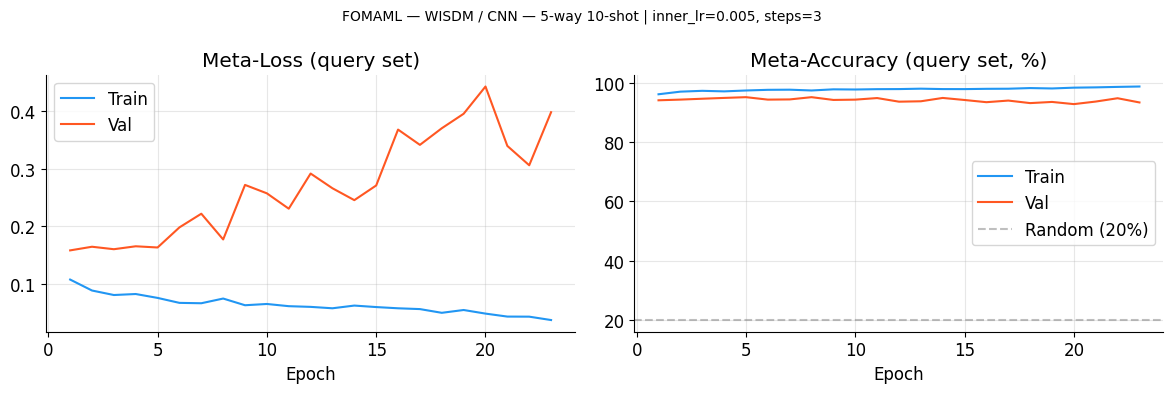

In [ ]:
epochs_ran = len(history['train_loss'])
ep         = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ep, history['train_loss'], label='Train', color='#2196F3')
axes[0].plot(ep, history['val_loss'],   label='Val',   color='#FF5722')
axes[0].set_title('Meta-Loss (query set)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(ep, [a*100 for a in history['train_acc']], label='Train', color='#2196F3')
axes[1].plot(ep, [a*100 for a in history['val_acc']],   label='Val',   color='#FF5722')
axes[1].axhline(y=100/n_way, color='gray', linestyle='--', alpha=0.5,
                label=f'Random ({100/n_way:.0f}%)')
axes[1].set_title('Meta-Accuracy (query set, %)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

fig.suptitle(
    f'FOMAML — {DATASET_NAME.upper()} / {BACKBONE_TYPE.upper()} — '
    f'{n_way}-way {TRAIN_K_SHOT}-shot | '
    f'inner_lr={MAML_INNER_LR}, steps={MAML_INNER_STEPS}',
    fontsize=10
)
plt.tight_layout()
plt.savefig(os.path.join(fsl_ckpt_dir, 'training_curves.png'), dpi=120)
plt.show()

## Cell 8 — Load Best Checkpoint and Generalization Evaluation

In [ ]:
# Load best meta-trained model
best_meta_model = BackboneClass(**backbone_kwargs).to(DEVICE)
ckpt_meta_info  = load_checkpoint(best_meta_model, fsl_ckpt_path)
print(f'✅ Best meta checkpoint loaded (epoch {ckpt_meta_info.get("epoch","?")})')

# Generalization: episodic eval on test users
print('\n── Generalization Evaluation (test users, episodic) ──')
print(f'{"K-shot":>8} {"Acc Mean":>12} {"±CI95":>10} {"Std":>8}')
print('─' * 42)

gen_results = {}
for k in K_SHOTS:
    loss_sum = 0.0
    acc_list = []
    for _ in range(N_EPISODES_EVAL):
        episode  = test_sampler.sample_episode(k_shot=k)
        sup_list = [episode['support_streams'][s].to(DEVICE) for s in stream_names]
        qry_list = [episode['query_streams'][s].to(DEVICE)   for s in stream_names]
        sup_lab  = episode['support_labels'].to(DEVICE)
        qry_lab  = episode['query_labels'].to(DEVICE)

        with torch.enable_grad():
            adapted = inner_loop_adapt(
                best_meta_model, sup_list, sup_lab, test_sampler.n_way,
                training=False
            )
        adapted.eval()
        with torch.no_grad():
            _, acc = compute_task_loss(adapted, qry_list, qry_lab, test_sampler.n_way)
        acc_list.append(acc)
        del adapted

    accs = np.array(acc_list)
    ci95 = 1.96 * accs.std() / np.sqrt(len(accs))
    gen_results[k] = {
        'acc_mean': float(accs.mean()),
        'acc_std' : float(accs.std()),
        'ci95'    : float(ci95),
    }
    print(
        f'{k:>8}-shot '
        f'{accs.mean()*100:>10.2f}% '
        f'{ci95*100:>8.2f}% '
        f'{accs.std()*100:>6.2f}%'
    )

✅ Best meta checkpoint loaded (epoch 8)

── Generalization Evaluation (test users, episodic) ──
  K-shot     Acc Mean      ±CI95      Std
──────────────────────────────────────────
       1-shot      91.86%     0.73%   5.25%
       5-shot      92.02%     0.79%   5.67%
      10-shot      93.17%     0.62%   4.50%


## Cell 9 — Personalization Evaluation

For each test user: clone meta-learned θ → inner loop on K-shot support  
→ evaluate on remaining user samples.

In [ ]:
# ─── Fix: use string-converted IDs throughout ─────────────────────────────────
sub_ids_str   = subject_ids.astype(str)
test_subjects = [str(s) for s in split_info['test']]

def maml_personalize_one_user(
    meta_model    : nn.Module,
    user_streams  : Dict[str, np.ndarray],
    user_y        : np.ndarray,
    k_shot        : int,
    n_trials      : int = 10,
    seed          : int = MASTER_SEED,
) -> Optional[Dict]:
    """
    MAML personalization for one test user.

    Inner loop adapts meta-learned initialization to this user.
    Evaluated on held-out query samples.

    Returns:
        dict with acc_before, acc_after, gain — or None
    """
    rng           = np.random.default_rng(seed)
    classes       = np.unique(user_y)
    valid_classes = [c for c in classes if (user_y == c).sum() > k_shot]

    if len(valid_classes) < 2:
        return None

    n_ep_way      = len(valid_classes)
    class_to_rel  = {c: i for i, c in enumerate(valid_classes)}

    trial_accs_before = []
    trial_accs_after  = []

    for trial in range(n_trials):
        support_idx = []
        query_idx   = []
        for c in valid_classes:
            c_idx = np.where(user_y == c)[0]
            rng.shuffle(c_idx)
            support_idx.extend(c_idx[:k_shot].tolist())
            query_idx.extend(c_idx[k_shot:].tolist())

        if not query_idx:
            continue

        sup_labels = torch.tensor(
            [class_to_rel[user_y[i]] for i in support_idx], dtype=torch.long
        ).to(DEVICE)
        qry_labels = torch.tensor(
            [class_to_rel[user_y[i]] for i in query_idx], dtype=torch.long
        ).to(DEVICE)

        sup_list = [
            torch.tensor(user_streams[s][support_idx], dtype=torch.float32).to(DEVICE)
            for s in stream_names
        ]
        qry_list = [
            torch.tensor(user_streams[s][query_idx], dtype=torch.float32).to(DEVICE)
            for s in stream_names
        ]

        # ── Acc BEFORE: meta-model without inner loop adaptation ───────────────
        meta_model.eval()
        with torch.no_grad():
            _, acc_before = compute_task_loss(
                meta_model, qry_list, qry_labels, n_ep_way
            )
        trial_accs_before.append(acc_before)

        # ── Acc AFTER: inner loop adapt on this user's support ────────────────
        with torch.enable_grad():
            adapted = inner_loop_adapt(
                meta_model, sup_list, sup_labels, n_ep_way,
                inner_lr    = MAML_INNER_LR,
                inner_steps = MAML_INNER_STEPS,
                training    = False,
            )

        adapted.eval()
        with torch.no_grad():
            _, acc_after = compute_task_loss(
                adapted, qry_list, qry_labels, n_ep_way
            )
        trial_accs_after.append(acc_after)
        del adapted

    if not trial_accs_after:
        return None

    ab = float(np.mean(trial_accs_before))
    aa = float(np.mean(trial_accs_after))
    return {
        'acc_before_mean' : ab,
        'acc_after_mean'  : aa,
        'gain'            : compute_personalization_gain(ab, aa),
        'acc_before_std'  : float(np.std(trial_accs_before)),
        'acc_after_std'   : float(np.std(trial_accs_after)),
        'n_trials'        : len(trial_accs_after),
        'n_valid_classes' : n_ep_way,
    }


print('── MAML Personalization Evaluation ──')
maml_results = {}

for k in K_SHOTS:
    maml_results[k] = []
    print(f'\n── K={k} shot ──')
    print(f'{"Subject":>10} {"Before":>10} {"After":>10} {"Gain":>10}')
    print('─' * 44)

    for subj in test_subjects:
        subj_mask = (sub_ids_str == subj)          # ← string comparison
        if subj_mask.sum() == 0:
            print(f'{subj:>10}  skipped (no data)')
            continue
        user_streams_np = {s: streams[s][subj_mask] for s in stream_names}
        user_y_np       = y[subj_mask]

        res = maml_personalize_one_user(
            best_meta_model, user_streams_np, user_y_np,
            k_shot=k, n_trials=10, seed=MASTER_SEED
        )
        if res is None:
            print(f'{subj:>10}  skipped (insufficient classes)')
            continue

        res['subject'] = subj
        maml_results[k].append(res)
        gain_sign = '+' if res['gain'] >= 0 else ''
        print(
            f'{subj:>10} '
            f'{res["acc_before_mean"]*100:>8.2f}% '
            f'{res["acc_after_mean"]*100:>8.2f}% '
            f'{gain_sign}{res["gain"]*100:>8.2f}%'
        )

    if maml_results[k]:
        mg = np.mean([r['gain'] for r in maml_results[k]])
        mb = np.mean([r['acc_before_mean'] for r in maml_results[k]])
        ma = np.mean([r['acc_after_mean']  for r in maml_results[k]])
        print(f'\n   Mean: before={mb*100:.2f}% | after={ma*100:.2f}% | gain={mg*100:+.2f}%')

── MAML Personalization Evaluation ──

── K=1 shot ──
   Subject     Before      After       Gain
────────────────────────────────────────────
      1649    96.86%    96.79%    -0.07%
      1602    93.83%    94.46% +    0.63%
      1636    93.70%    94.61% +    0.91%
      1633    90.64%    91.68% +    1.04%
      1601    98.98%    98.74%    -0.24%
      1613    98.59%    98.54%    -0.05%
      1608    97.81%    98.24% +    0.43%

   Mean: before=95.77% | after=96.15% | gain=+0.38%

── K=5 shot ──
   Subject     Before      After       Gain
────────────────────────────────────────────
      1649    96.85%    96.82%    -0.03%
      1602    94.02%    94.79% +    0.78%
      1636    93.79%    94.74% +    0.95%
      1633    90.76%    91.87% +    1.11%
      1601    98.97%    98.91%    -0.07%
      1613    98.59%    98.53%    -0.07%
      1608    97.91%    98.46% +    0.56%

   Mean: before=95.84% | after=96.30% | gain=+0.46%

── K=10 shot ──
   Subject     Before      After       Gain
───

## Cell 10 — Gain Summary and Registry

In [ ]:
print('── MAML Personalization Gain Summary ──')
print(f'{"K-shot":>8} {"Acc Before":>12} {"Acc After":>12} {"Gain":>10} {"CI95":>10}')
print('─' * 58)

all_summary_results = []

for k in K_SHOTS:
    if not maml_results[k]:
        continue

    accs_before = [r['acc_before_mean'] for r in maml_results[k]]
    accs_after  = [r['acc_after_mean']  for r in maml_results[k]]
    gains       = [r['gain']            for r in maml_results[k]]

    ab   = float(np.mean(accs_before))
    aa   = float(np.mean(accs_after))
    gain = float(np.mean(gains))
    ci95 = float(1.96 * np.std(gains) / np.sqrt(len(gains)))

    print(
        f'{k:>8}-shot '
        f'{ab*100:>10.2f}% '
        f'{aa*100:>10.2f}% '
        f'{gain*100:>+9.2f}% '
        f'{ci95*100:>8.2f}%'
    )

    result = {
        'dataset'      : DATASET_NAME,
        'backbone'     : BACKBONE_TYPE,
        'method'       : 'maml',
        'k_shot'       : k,
        'seed'         : MASTER_SEED,
        'acc_before'   : ab,
        'acc_after'    : aa,
        'gain'         : gain,
        'ci95'         : ci95,
        'inner_lr'     : MAML_INNER_LR,
        'inner_steps'  : MAML_INNER_STEPS,
        'n_test_users' : len(maml_results[k]),
    }
    config_key = make_config_key(DATASET_NAME, BACKBONE_TYPE, 'maml', k, MASTER_SEED)
    mark_completed(config_key, result)
    all_summary_results.append(result)

print(f'\n✅ Results saved to registry')

── MAML Personalization Gain Summary ──
  K-shot   Acc Before    Acc After       Gain       CI95
──────────────────────────────────────────────────────────
       1-shot      95.77%      96.15%     +0.38%     0.35%
       5-shot      95.84%      96.30%     +0.46%     0.35%
      10-shot      95.88%      96.36%     +0.48%     0.36%

✅ Results saved to registry


## Cell 11 — K-Shot Curve Plot

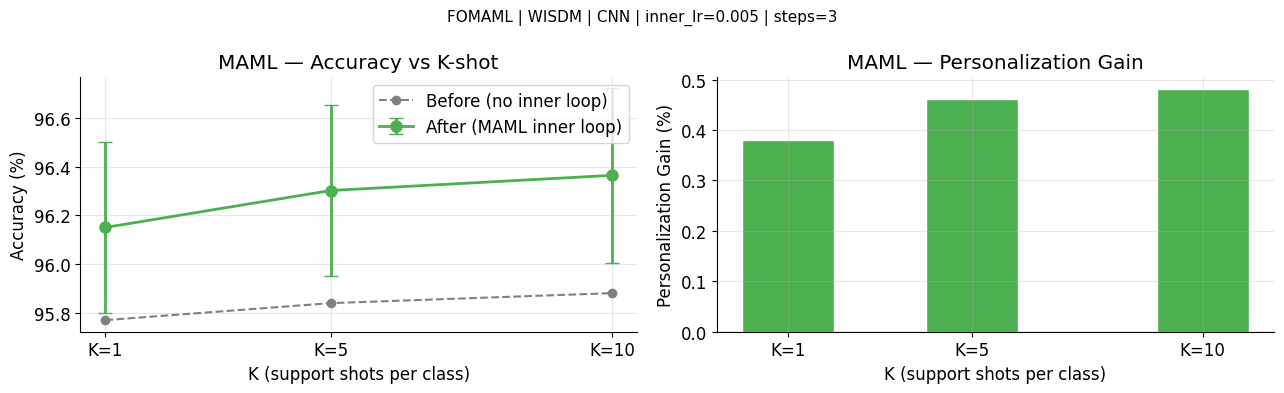

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/maml/kshot_curves.png


In [ ]:
if all_summary_results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ks          = [r['k_shot']     for r in all_summary_results]
    accs_before = [r['acc_before'] for r in all_summary_results]
    accs_after  = [r['acc_after']  for r in all_summary_results]
    gains       = [r['gain']       for r in all_summary_results]
    ci95s       = [r['ci95']       for r in all_summary_results]

    axes[0].plot(ks, [a*100 for a in accs_before], 'o--',
                 color='gray', label='Before (no inner loop)', linewidth=1.5)
    axes[0].errorbar(
        ks, [a*100 for a in accs_after],
        yerr=[c*100 for c in ci95s],
        fmt='o-', color=METHOD_COLORS['maml'],
        label='After (MAML inner loop)',
        linewidth=2, capsize=5, markersize=8
    )
    axes[0].set_xticks(ks)
    axes[0].set_xlabel('K (support shots per class)')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title('MAML — Accuracy vs K-shot')
    axes[0].legend()

    bar_colors = [METHOD_COLORS['maml'] if g >= 0 else '#FF5722' for g in gains]
    axes[1].bar(ks, [g*100 for g in gains], color=bar_colors, edgecolor='white', width=2)
    axes[1].axhline(y=0, color='black', linewidth=0.8)
    axes[1].set_xticks(ks)
    axes[1].set_xlabel('K (support shots per class)')
    axes[1].set_ylabel('Personalization Gain (%)')
    axes[1].set_title('MAML — Personalization Gain')

    for ax in axes:
        ax.set_xticklabels([f'K={k}' for k in ks])

    fig.suptitle(
        f'FOMAML | {DATASET_NAME.upper()} | {BACKBONE_TYPE.upper()} | '
        f'inner_lr={MAML_INNER_LR} | steps={MAML_INNER_STEPS}',
        fontsize=11
    )
    plt.tight_layout()
    plot_path = os.path.join(fsl_ckpt_dir, 'kshot_curves.png')
    plt.savefig(plot_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {plot_path}')

## Cell 12 — Final Summary

In [ ]:
print('=' * 65)
print('  FOMAML COMPLETE')
print('=' * 65)
print(f'  Dataset          : {DATASET_NAME}')
print(f'  Backbone         : {BACKBONE_TYPE}')
print(f'  Inner LR         : {MAML_INNER_LR}')
print(f'  Inner steps      : {MAML_INNER_STEPS}')
print(f'  Outer LR         : {MAML_OUTER_LR}')
print(f'  Best meta val acc: {best_val_acc*100:.2f}%')
print()
print(f'  Results:')
print(f'  {"K":>4}  {"Before":>8}  {"After":>8}  {"Gain":>8}  {"CI95":>8}')
print(f'  {"-"*46}')
for r in all_summary_results:
    print(
        f'  {r["k_shot"]:>4}  '
        f'{r["acc_before"]*100:>7.2f}%  '
        f'{r["acc_after"]*100:>7.2f}%  '
        f'{r["gain"]*100:>+7.2f}%  '
        f'±{r["ci95"]*100:>5.2f}%'
    )
print('=' * 65)
print()
print('  FOMAML note:')
print('  Second-order gradients dropped (first-order approximation).')
print('  Inner loop uses SGD. Outer loop uses Adam.')
print()
print('  Next steps:')
print('  → Notebook 11 (Supervised Contrastive FSL) — last FSL method')
print('  → After all 4 methods: notebook 14 (experiment runner)')
print('=' * 65)

  FOMAML COMPLETE
  Dataset          : wisdm
  Backbone         : cnn
  Inner LR         : 0.005
  Inner steps      : 3
  Outer LR         : 0.0005
  Best meta val acc: 95.09%

  Results:
     K    Before     After      Gain      CI95
  ----------------------------------------------
     1    95.77%    96.15%    +0.38%  ± 0.35%
     5    95.84%    96.30%    +0.46%  ± 0.35%
    10    95.88%    96.36%    +0.48%  ± 0.36%

  FOMAML note:
  Second-order gradients dropped (first-order approximation).
  Inner loop uses SGD. Outer loop uses Adam.

  Next steps:
  → Notebook 11 (Supervised Contrastive FSL) — last FSL method
  → After all 4 methods: notebook 14 (experiment runner)
